Data path: /content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR/

HAR Reconcile v3.1 — Improved Encoders + Focal/Smoothing Loss
Device: cuda

Loading UCI-HAR from: /content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR/
  Train: (7352, 128, 9), Test: (2947, 128, 9)
  After preprocessing: train=(7352, 9, 128), test=(2947, 9, 128)
  Model parameters: 1,143,467

Ep   1/120 | lr=3.7e-05 | Tr acc=0.6954 F1=0.6295 | Va acc=0.7326 F1=0.6731 | λ=0.543±0.000 | 15.8s
Ep   5/120 | lr=1.9e-04 | Tr acc=0.9349 F1=0.9383 | Va acc=0.9026 F1=0.9018 | λ=0.451±0.012 | 6.3s
Ep  10/120 | lr=3.0e-04 | Tr acc=0.9582 F1=0.9614 | Va acc=0.9389 F1=0.9395 | λ=0.488±0.085 | 6.1s
Ep  15/120 | lr=3.0e-04 | Tr acc=0.9677 F1=0.9699 | Va acc=0.9382 F1=0.9398 | λ=0.509±0.111 | 6.5s
Ep  20/120 | lr=2.9e-04 | Tr acc=0.9762 F1=0.9780 | Va acc=0.9406 F1=0.9417 | λ=0.507±0.127 | 7.3s
Ep  25/120 | lr=2.9e-04 | Tr acc=0.9812 F1=0.9826 | Va acc=0.9532 F1=0.9541 | λ=0.514±0.131 | 10.4s
Ep  30/120 | lr=2.7e-04 | Tr acc=0.9811 

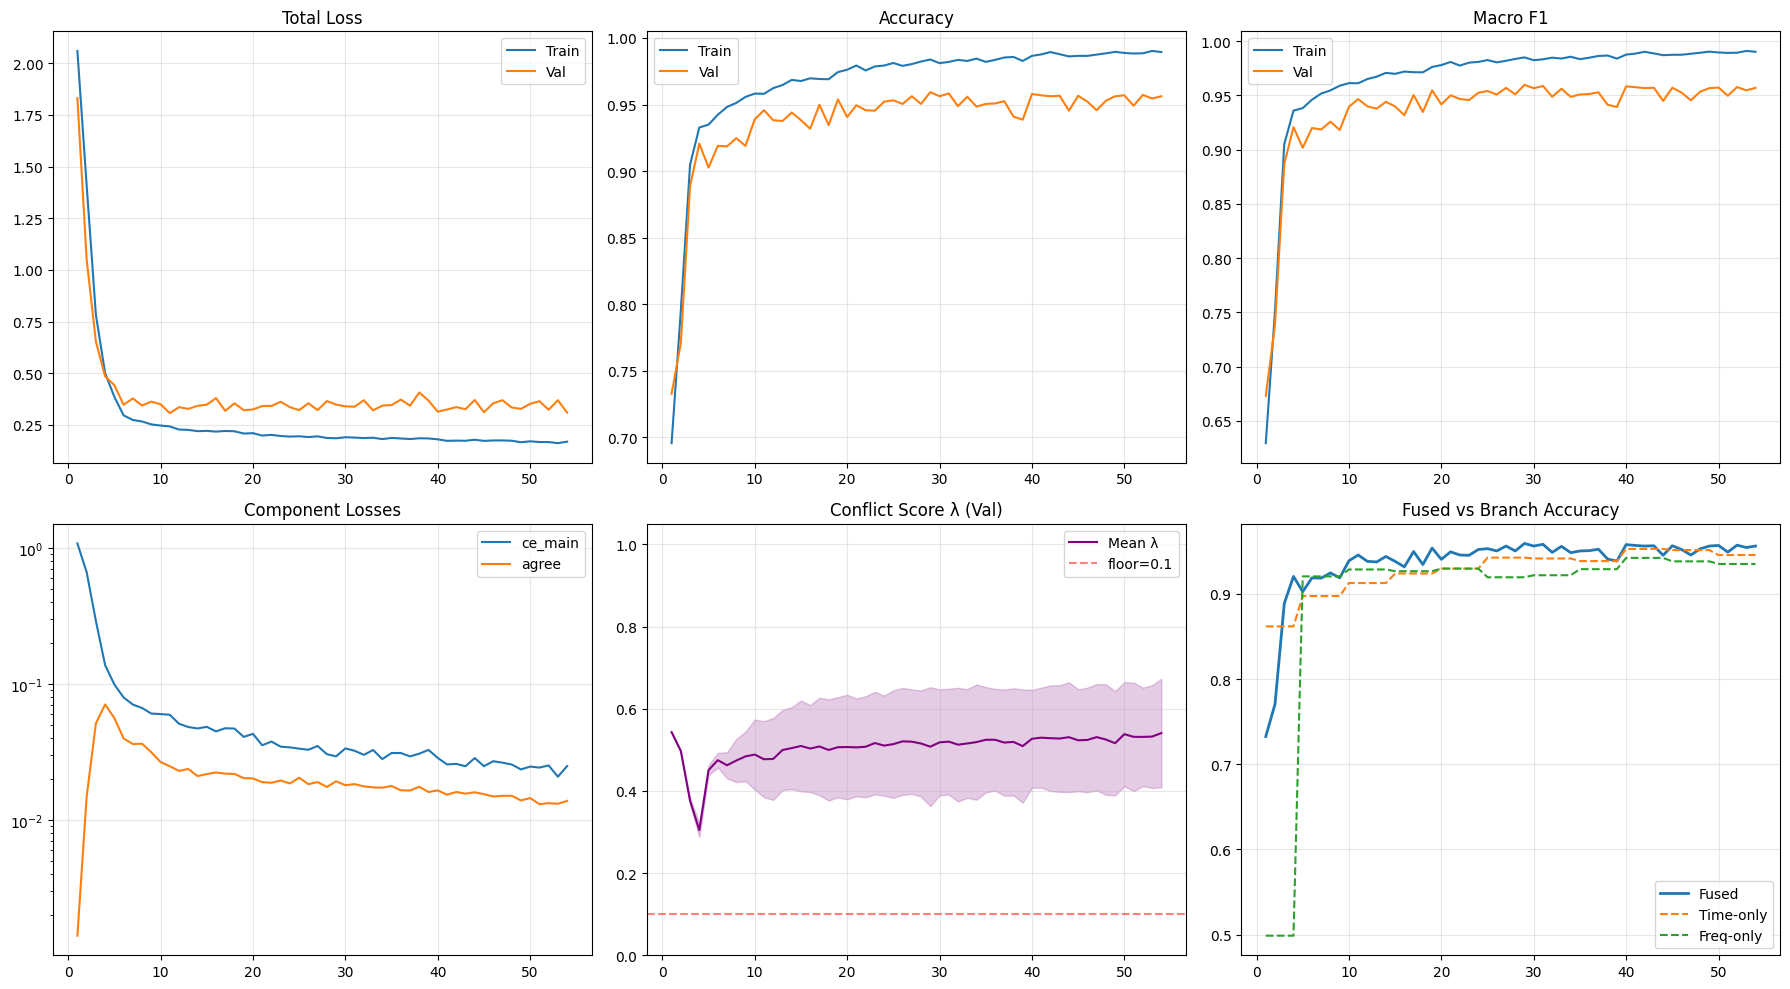

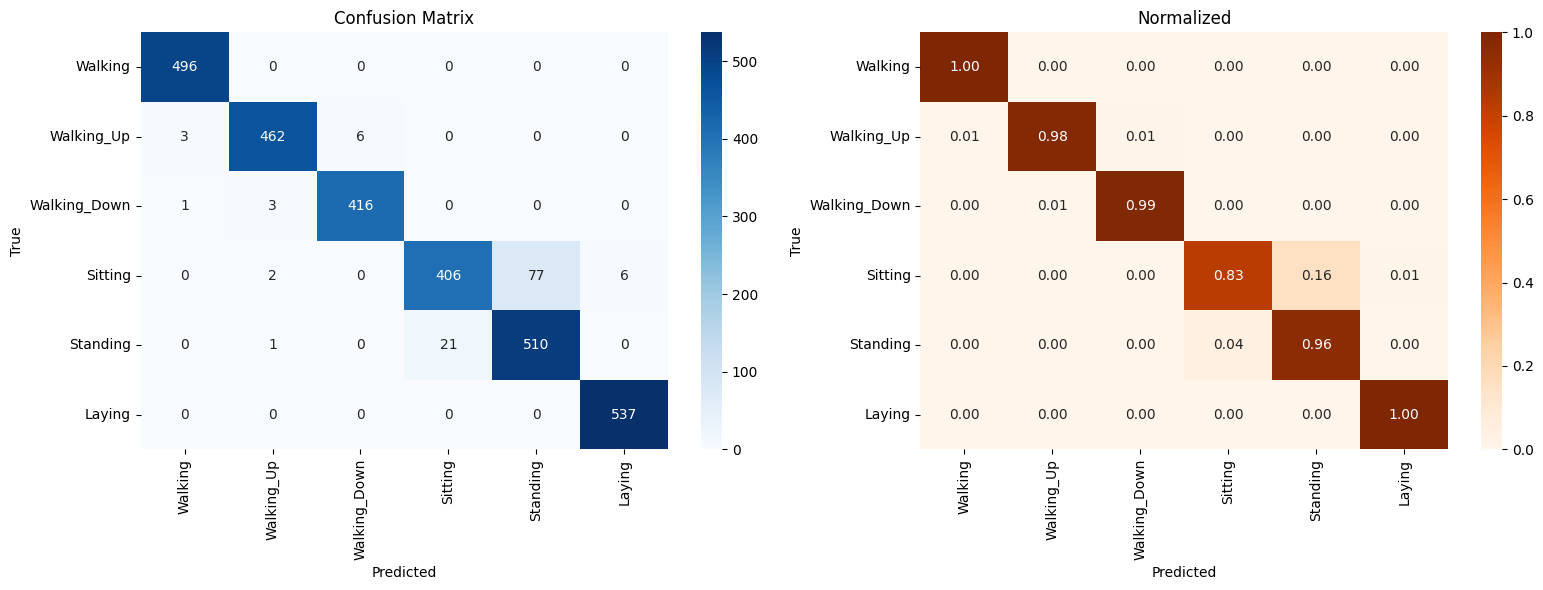

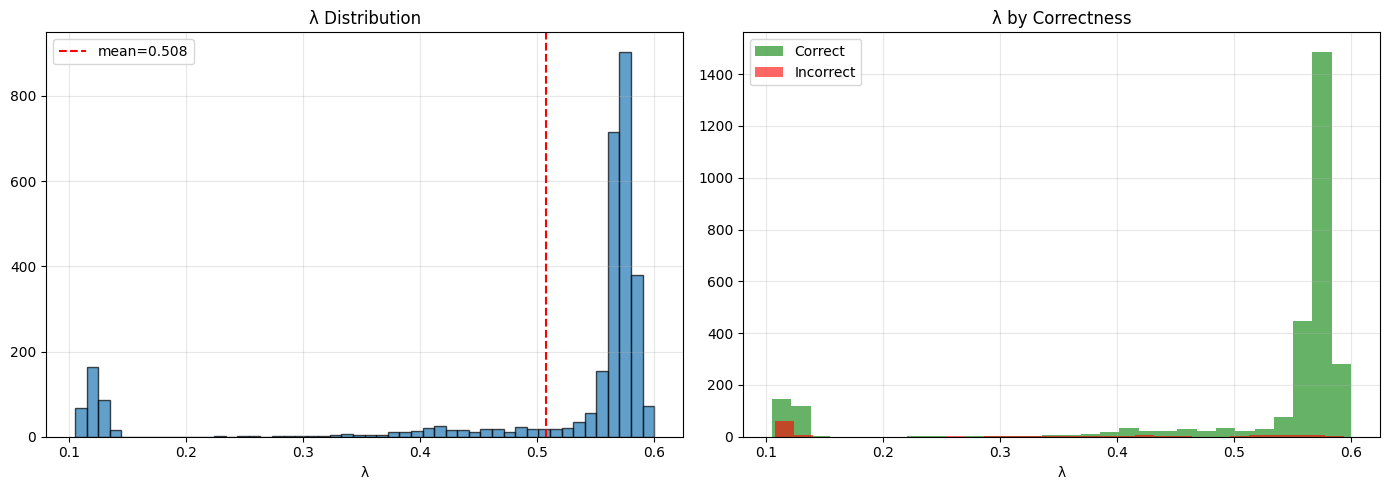

  Model saved to results/har_reconcile_v31_best.pt


In [12]:
"""
=============================================================================
HAR Reconcile Pipeline v3.1 — Improved
  개선점:
    1) FreqEncoder: deeper (4-layer ResBlock CNN), wider channels (32→64→128→256)
    2) TimeEncoder: 더 많은 Perceiver blocks (2→4), latent dim 증가
    3) Loss: Label Smoothing CE + Focal Loss + Poly1 Loss 옵션
    4) Branch-aware focal weighting
=============================================================================
"""

import os
import math
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')


# ============================================================================
# Config
# ============================================================================
class Config:
    # === Data ===
    data_dir = "/content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR/"
    n_channels = 9
    seq_len = 128
    n_classes = 6

    # === Frequency branch ===
    stft_bins_per_scale = 16
    stft_kernel_sizes = [16, 32, 64]   # 3-scale (추가)
    stft_hop = 4                        # hop 줄여서 time resolution 향상
    freq_cnn_dim = 128                  # 원래 dim 유지

    # === Time branch ===
    latent_n = 36                       # 32 → 36 (소폭 증가)
    latent_d = 128                      # 원래 dim 유지
    perceiver_heads = 4
    perceiver_blocks = 3                # 2 → 3 (소폭 증가)
    perceiver_dim = 128                 # 원래 dim 유지
    dropout = 0.15

    # === Training ===
    batch_size = 64
    epochs = 120
    lr = 3e-4
    weight_decay = 1e-4
    warmup_epochs = 8

    # === Loss ===
    label_smoothing = 0.1               # NEW
    focal_gamma = 2.0                   # NEW: focal loss gamma
    focal_alpha = None                  # NEW: None = uniform, or list of per-class weights
    alpha_agree = 0.3                   # 0.5 → 0.3 (branch가 강해지면 줄여도 됨)
    lambda_floor = 0.1
    lambda_ent_weight = 0.05           # 0.1 → 0.05
    branch_loss_weight = 0.3

    # === Misc ===
    seed = 42
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    activity_labels = [
        'Walking', 'Walking_Up', 'Walking_Down',
        'Sitting', 'Standing', 'Laying'
    ]


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================================
# Data Loading (unchanged)
# ============================================================================
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]


def load_uci_har_split(data_dir, split='train'):
    inertial_dir = os.path.join(data_dir, split, "Inertial Signals")
    signals = []
    for sig in SIGNALS:
        fpath = os.path.join(inertial_dir, f"{sig}_{split}.txt")
        data = np.loadtxt(fpath, dtype=np.float32)
        signals.append(data)
    X = np.stack(signals, axis=-1)
    y = np.loadtxt(os.path.join(data_dir, split, f"y_{split}.txt"), dtype=np.int32) - 1
    return X, y


def load_uci_har(cfg):
    print(f"Loading UCI-HAR from: {cfg.data_dir}")
    X_train_raw, y_train = load_uci_har_split(cfg.data_dir, 'train')
    X_test_raw, y_test = load_uci_har_split(cfg.data_dir, 'test')
    print(f"  Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")

    N_tr, T, C = X_train_raw.shape
    N_te = X_test_raw.shape[0]

    scaler = StandardScaler()
    scaler.fit(X_train_raw.reshape(-1, C))

    X_train = scaler.transform(X_train_raw.reshape(-1, C)).reshape(N_tr, T, C)
    X_test = scaler.transform(X_test_raw.reshape(-1, C)).reshape(N_te, T, C)

    X_train = X_train.transpose(0, 2, 1)
    X_test = X_test.transpose(0, 2, 1)

    print(f"  After preprocessing: train={X_train.shape}, test={X_test.shape}")
    return X_train, y_train, X_test, y_test


class HARDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if torch.rand(1).item() < 0.5:
                x = x * (1.0 + 0.1 * torch.randn(x.size(0), 1))
            if torch.rand(1).item() < 0.5:
                x = x + 0.02 * torch.randn_like(x)
            if torch.rand(1).item() < 0.3:
                ch = torch.randint(0, x.size(0), (1,)).item()
                x[ch] = 0.0
            # NEW: time shift augmentation
            if torch.rand(1).item() < 0.3:
                shift = torch.randint(-5, 6, (1,)).item()
                x = torch.roll(x, shifts=shift, dims=-1)
        return x, self.y[idx]


# ============================================================================
# Model Components (IMPROVED)
# ============================================================================
class MultiScaleLearnableSTFT(nn.Module):
    """Multi-scale learnable filterbank — 3 scales."""
    def __init__(self, in_ch, bins_per_scale=16, kernel_sizes=[16, 32, 64], hop=4):
        super().__init__()
        self.banks = nn.ModuleList()
        self.norms = nn.ModuleList()

        for ks in kernel_sizes:
            self.banks.append(
                nn.Conv1d(in_ch, bins_per_scale, kernel_size=ks,
                          stride=hop, padding=ks // 2, bias=False)
            )
            self.norms.append(nn.BatchNorm1d(bins_per_scale))

    def forward(self, x):
        specs = []
        for conv, bn in zip(self.banks, self.norms):
            c = conv(x)
            mag = torch.sqrt(c ** 2 + 1e-6)
            logmag = bn(torch.log1p(mag))
            specs.append(logmag)
        min_t = min(s.size(2) for s in specs)
        specs = [s[:, :, :min_t] for s in specs]
        return torch.cat(specs, dim=1).unsqueeze(1)


# ---------- Improved FreqEncoder with Residual Blocks ----------
class ResBlock2d(nn.Module):
    """Pre-activation ResBlock for 2D CNN."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, stride=stride, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.act = nn.GELU()

        self.shortcut = nn.Identity()
        if in_ch != out_ch or stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = self.act(self.bn1(x))
        out = self.conv1(out)
        out = self.act(self.bn2(out))
        out = self.conv2(out)
        return out + self.shortcut(x)


class FreqEncoder(nn.Module):
    """ResNet-style 2D-CNN — lighter channels (24→48→96)."""
    def __init__(self, out_dim=128):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 24, 3, padding=1, bias=False),
            nn.BatchNorm2d(24),
            nn.GELU(),
        )
        self.layer1 = ResBlock2d(24, 48, stride=2)
        self.layer2 = ResBlock2d(48, 96, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(96, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        h = self.stem(x)
        h = self.layer1(h)
        h = self.layer2(h)
        h = self.pool(h).view(x.size(0), -1)
        return self.fc(h)


# ---------- Improved Perceiver Time Encoder ----------
class PerceiverCrossAttention(nn.Module):
    def __init__(self, d_latent, d_input, n_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            d_latent, n_heads, batch_first=True, dropout=dropout
        )
        self.norm_q = nn.LayerNorm(d_latent)
        self.norm_kv = nn.LayerNorm(d_input)
        self.proj_kv = nn.Linear(d_input, d_latent) if d_input != d_latent else nn.Identity()

    def forward(self, latents, inputs):
        q = self.norm_q(latents)
        kv = self.proj_kv(self.norm_kv(inputs))
        out, _ = self.attn(q, kv, kv)
        return latents + out


class PerceiverSelfBlock(nn.Module):
    def __init__(self, d_latent, n_heads=4, ff_mult=3, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_latent)
        self.attn = nn.MultiheadAttention(
            d_latent, n_heads, batch_first=True, dropout=dropout
        )
        self.norm2 = nn.LayerNorm(d_latent)
        self.ffn = nn.Sequential(
            nn.Linear(d_latent, d_latent * ff_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_latent * ff_mult, d_latent),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        h = self.norm1(x)
        x = x + self.attn(h, h, h)[0]
        x = x + self.ffn(self.norm2(x))
        return x


class PerceiverTimeEncoder(nn.Module):
    """Improved: 2-stage cross-attention, ff_mult=3."""
    def __init__(self, in_dim, latent_n=36, latent_d=128, n_heads=4,
                 num_blocks=3, out_dim=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, latent_d),
            nn.LayerNorm(latent_d),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.pos_enc = nn.Parameter(torch.randn(1, 512, latent_d) * 0.02)
        self.latents = nn.Parameter(torch.randn(1, latent_n, latent_d) * 0.02)

        # 2-stage cross attention (beginning + midpoint)
        self.cross_attn_1 = PerceiverCrossAttention(latent_d, latent_d, n_heads, dropout)
        self.cross_attn_2 = PerceiverCrossAttention(latent_d, latent_d, n_heads, dropout)

        mid = num_blocks // 2
        self.self_blocks_1 = nn.ModuleList([
            PerceiverSelfBlock(latent_d, n_heads, ff_mult=3, dropout=dropout)
            for _ in range(mid)
        ])
        self.self_blocks_2 = nn.ModuleList([
            PerceiverSelfBlock(latent_d, n_heads, ff_mult=3, dropout=dropout)
            for _ in range(num_blocks - mid)
        ])

        self.norm_out = nn.LayerNorm(latent_d)
        self.fc_out = nn.Sequential(
            nn.Linear(latent_d, out_dim),
            nn.LayerNorm(out_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        B, T, _ = x.shape
        inp = self.input_proj(x) + self.pos_enc[:, :T, :]
        latents = self.latents.expand(B, -1, -1)

        # Stage 1: cross-attn → self-attn blocks
        latents = self.cross_attn_1(latents, inp)
        for blk in self.self_blocks_1:
            latents = blk(latents)

        # Stage 2: re-attend to input → more self-attn
        latents = self.cross_attn_2(latents, inp)
        for blk in self.self_blocks_2:
            latents = blk(latents)

        return self.fc_out(self.norm_out(latents).mean(dim=1))


# ---------- Reconciliation (unchanged) ----------
class CrossDomainReconciliation(nn.Module):
    def __init__(self, feat_dim, n_heads=4, dropout=0.1):
        super().__init__()
        self.cross_t2f = nn.MultiheadAttention(
            feat_dim, n_heads, batch_first=True, dropout=dropout
        )
        self.cross_f2t = nn.MultiheadAttention(
            feat_dim, n_heads, batch_first=True, dropout=dropout
        )
        self.norm_t = nn.LayerNorm(feat_dim)
        self.norm_f = nn.LayerNorm(feat_dim)

        self.gate = nn.Sequential(
            nn.Linear(feat_dim * 2, feat_dim),
            nn.Sigmoid()
        )
        self.out_proj = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.LayerNorm(feat_dim),
            nn.GELU()
        )

    def forward(self, z_t, z_f):
        z_t_seq = z_t.unsqueeze(1)
        z_f_seq = z_f.unsqueeze(1)

        z_t2f, _ = self.cross_t2f(self.norm_t(z_t_seq), self.norm_f(z_f_seq), self.norm_f(z_f_seq))
        z_f2t, _ = self.cross_f2t(self.norm_f(z_f_seq), self.norm_t(z_t_seq), self.norm_t(z_t_seq))

        z_t2f = z_t2f.squeeze(1)
        z_f2t = z_f2t.squeeze(1)

        gate = self.gate(torch.cat([z_t2f, z_f2t], dim=-1))
        fused = gate * z_t2f + (1.0 - gate) * z_f2t
        return self.out_proj(fused)


class ConflictEstimator(nn.Module):
    def __init__(self, n_features=5, lambda_floor=0.1):
        super().__init__()
        self.lambda_floor = lambda_floor
        self.mlp = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )

    def forward(self, z_t, z_f, p_t, p_f):
        z_t_d, z_f_d = z_t.detach(), z_f.detach()
        p_t_d, p_f_d = p_t.detach(), p_f.detach()

        cos_sim = F.cosine_similarity(z_t_d, z_f_d, dim=-1, eps=1e-6)
        l2_dist = torch.norm(z_t_d - z_f_d, dim=-1, p=2)
        ent_t = -(p_t_d * (p_t_d + 1e-8).log()).sum(dim=-1)
        ent_f = -(p_f_d * (p_f_d + 1e-8).log()).sum(dim=-1)
        top1_agree = (p_t_d.argmax(-1) == p_f_d.argmax(-1)).float()

        features = torch.stack([cos_sim, l2_dist, ent_t, ent_f, top1_agree], dim=-1)
        raw = torch.sigmoid(self.mlp(features).squeeze(-1))
        return self.lambda_floor + (1.0 - self.lambda_floor) * raw


class BranchClassifier(nn.Module):
    def __init__(self, feat_dim, n_classes, dropout=0.15):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, n_classes),
        )

    def forward(self, x):
        return self.head(x)


# ============================================================================
# Full Model
# ============================================================================
class HARReconcileModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        self.stft = MultiScaleLearnableSTFT(
            in_ch=cfg.n_channels,
            bins_per_scale=cfg.stft_bins_per_scale,
            kernel_sizes=cfg.stft_kernel_sizes,
            hop=cfg.stft_hop,
        )
        self.freq_encoder = FreqEncoder(out_dim=cfg.freq_cnn_dim)

        self.time_encoder = PerceiverTimeEncoder(
            in_dim=cfg.n_channels,
            latent_n=cfg.latent_n,
            latent_d=cfg.latent_d,
            n_heads=cfg.perceiver_heads,
            num_blocks=cfg.perceiver_blocks,
            out_dim=cfg.perceiver_dim,
            dropout=cfg.dropout,
        )

        assert cfg.freq_cnn_dim == cfg.perceiver_dim
        feat_dim = cfg.perceiver_dim

        self.reconciliation = CrossDomainReconciliation(
            feat_dim=feat_dim, n_heads=4, dropout=cfg.dropout
        )

        self.cls_time = BranchClassifier(feat_dim, cfg.n_classes, cfg.dropout)
        self.cls_freq = BranchClassifier(feat_dim, cfg.n_classes, cfg.dropout)

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, feat_dim),
            nn.GELU(),
            nn.Dropout(cfg.dropout),
            nn.Linear(feat_dim, cfg.n_classes),
        )

        self.conflict_est = ConflictEstimator(n_features=5, lambda_floor=cfg.lambda_floor)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.Conv1d, nn.Conv2d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        spec = self.stft(x)
        z_f = self.freq_encoder(spec)
        z_t = self.time_encoder(x.permute(0, 2, 1))

        logits_t = self.cls_time(z_t)
        logits_f = self.cls_freq(z_f)
        p_t = F.softmax(logits_t, dim=-1)
        p_f = F.softmax(logits_f, dim=-1)

        lam = self.conflict_est(z_t, z_f, p_t, p_f)
        z_fused = self.reconciliation(z_t, z_f)
        logits = self.classifier(z_fused)

        features = {
            'z_t': z_t, 'z_f': z_f, 'z_fused': z_fused,
            'lam': lam, 'p_t': p_t, 'p_f': p_f,
        }
        return logits, logits_t, logits_f, features


# ============================================================================
# Loss (IMPROVED)
# ============================================================================
class FocalLoss(nn.Module):
    """Focal Loss with label smoothing support."""
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, logits, targets):
        n_classes = logits.size(-1)

        # Soft targets with label smoothing
        if self.label_smoothing > 0:
            with torch.no_grad():
                smooth = torch.full_like(logits, self.label_smoothing / (n_classes - 1))
                smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        else:
            smooth = F.one_hot(targets, n_classes).float()

        log_prob = F.log_softmax(logits, dim=-1)
        prob = log_prob.exp()

        # Focal weight: (1 - p_t)^gamma
        # p_t = probability of true class
        p_t = (prob * smooth).sum(dim=-1)
        focal_weight = (1.0 - p_t) ** self.gamma

        loss = -(smooth * log_prob).sum(dim=-1)

        # Class-level alpha weighting
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            loss = alpha_t * focal_weight * loss
        else:
            loss = focal_weight * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


class ReconcileLoss(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # Main loss: Focal + Label Smoothing
        self.focal = FocalLoss(
            gamma=cfg.focal_gamma,
            label_smoothing=cfg.label_smoothing,
            reduction='mean'
        )

        # Branch loss: lighter smoothing, no focal (branch는 단순 CE + smoothing)
        self.branch_ce = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing * 0.5)

    def forward(self, logits, logits_t, logits_f, features, labels):
        losses = {}

        # 1. Main: Focal Loss with label smoothing
        l_ce_main = self.focal(logits, labels)

        # Branch: lighter regularization
        l_ce_t = self.branch_ce(logits_t, labels)
        l_ce_f = self.branch_ce(logits_f, labels)

        losses['ce_main'] = l_ce_main
        losses['ce_t'] = l_ce_t
        losses['ce_f'] = l_ce_f

        l_ce = l_ce_main + self.cfg.branch_loss_weight * (l_ce_t + l_ce_f)

        # 2. Agreement loss
        p_t = features['p_t']
        p_f = features['p_f']

        kl_tf = F.kl_div((p_t + 1e-8).log(), p_f, reduction='none').sum(dim=-1)
        kl_ft = F.kl_div((p_f + 1e-8).log(), p_t, reduction='none').sum(dim=-1)
        l_agree_raw = 0.5 * (kl_tf + kl_ft)

        lam = features['lam']
        l_agree = (lam * l_agree_raw).mean()
        losses['agree'] = l_agree

        # 3. Lambda entropy
        l_lam_ent = -self.cfg.lambda_ent_weight * self._lambda_entropy(lam)
        losses['lam_ent'] = l_lam_ent

        total = l_ce + self.cfg.alpha_agree * l_agree + l_lam_ent
        losses['total'] = total
        return total, losses

    def _lambda_entropy(self, lam):
        floor = self.cfg.lambda_floor
        p = ((lam - floor) / (1.0 - floor + 1e-8)).clamp(1e-6, 1 - 1e-6)
        ent = -(p * p.log() + (1 - p) * (1 - p).log())
        return ent.mean()


# ============================================================================
# Scheduler
# ============================================================================
class CosineWarmupScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.base_lr = optimizer.param_groups[0]['lr']
        self.min_lr = min_lr

    def step(self, epoch):
        if epoch < self.warmup_epochs:
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / max(1, self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr
        return lr


# ============================================================================
# Training & Evaluation
# ============================================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_accum = defaultdict(float)
    all_preds, all_labels = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, logits_t, logits_f, features = model(x)
        loss, losses = criterion(logits, logits_t, logits_f, features, y)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        B = x.size(0)
        for k, v in losses.items():
            loss_accum[k] += v.item() * B

        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    n = len(all_labels)
    avg_losses = {k: v / n for k, v in loss_accum.items()}
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_losses, acc, f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_accum = defaultdict(float)
    all_preds, all_labels, all_lam = [], [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits, logits_t, logits_f, features = model(x)
        loss, losses = criterion(logits, logits_t, logits_f, features, y)

        B = x.size(0)
        for k, v in losses.items():
            loss_accum[k] += v.item() * B

        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())
        all_lam.extend(features['lam'].cpu().numpy())

    n = len(all_labels)
    avg_losses = {k: v / n for k, v in loss_accum.items()}
    metrics = {
        'acc': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds, average='macro'),
        'precision': precision_score(all_labels, all_preds, average='macro'),
        'recall': recall_score(all_labels, all_preds, average='macro'),
        'mean_lambda': np.mean(all_lam),
        'std_lambda': np.std(all_lam),
    }
    return avg_losses, metrics, np.array(all_preds), np.array(all_labels)


@torch.no_grad()
def evaluate_branches(model, loader, device):
    model.eval()
    all_t, all_f, all_y = [], [], []
    for x, y in loader:
        x = x.to(device)
        _, logits_t, logits_f, _ = model(x)
        all_t.extend(logits_t.argmax(dim=-1).cpu().numpy())
        all_f.extend(logits_f.argmax(dim=-1).cpu().numpy())
        all_y.extend(y.numpy())
    y = np.array(all_y)
    return {
        'time_acc': accuracy_score(y, all_t),
        'freq_acc': accuracy_score(y, all_f),
        'time_f1': f1_score(y, all_t, average='macro'),
        'freq_f1': f1_score(y, all_f, average='macro'),
    }


# ============================================================================
# Visualization
# ============================================================================
def plot_training_curves(history, save_path=None):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    epochs = range(1, len(history['train_acc']) + 1)

    axes[0, 0].plot(epochs, history['train_loss'], label='Train')
    axes[0, 0].plot(epochs, history['val_loss'], label='Val')
    axes[0, 0].set_title('Total Loss'); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(epochs, history['train_acc'], label='Train')
    axes[0, 1].plot(epochs, history['val_acc'], label='Val')
    axes[0, 1].set_title('Accuracy'); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

    axes[0, 2].plot(epochs, history['train_f1'], label='Train')
    axes[0, 2].plot(epochs, history['val_f1'], label='Val')
    axes[0, 2].set_title('Macro F1'); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

    for key in ['ce_main', 'agree']:
        if f'train_{key}' in history:
            axes[1, 0].plot(epochs, history[f'train_{key}'], label=key)
    axes[1, 0].set_title('Component Losses'); axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3); axes[1, 0].set_yscale('log')

    if 'val_lambda' in history:
        axes[1, 1].plot(epochs, history['val_lambda'], label='Mean λ', color='purple')
        if 'val_lambda_std' in history:
            m = np.array(history['val_lambda'])
            s = np.array(history['val_lambda_std'])
            axes[1, 1].fill_between(epochs, m - s, m + s, alpha=0.2, color='purple')
        axes[1, 1].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='floor=0.1')
        axes[1, 1].set_title('Conflict Score λ (Val)'); axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3); axes[1, 1].set_ylim(0, 1.05)

    axes[1, 2].plot(epochs, history['val_acc'], label='Fused', linewidth=2)
    if 'val_branch_t_acc' in history:
        axes[1, 2].plot(epochs, history['val_branch_t_acc'], label='Time-only', linestyle='--')
    if 'val_branch_f_acc' in history:
        axes[1, 2].plot(epochs, history['val_branch_f_acc'], label='Freq-only', linestyle='--')
    axes[1, 2].set_title('Fused vs Branch Accuracy'); axes[1, 2].legend(); axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, labels, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax1)
    ax1.set_title('Confusion Matrix'); ax1.set_ylabel('True'); ax1.set_xlabel('Predicted')
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges', xticklabels=labels, yticklabels=labels, ax=ax2)
    ax2.set_title('Normalized'); ax2.set_ylabel('True'); ax2.set_xlabel('Predicted')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_lambda_distribution(model, loader, device, save_path=None):
    model.eval()
    all_lam, all_correct = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits, _, _, features = model(x)
            all_lam.extend(features['lam'].cpu().numpy())
            all_correct.extend((logits.argmax(dim=-1) == y).cpu().numpy())
    lam = np.array(all_lam)
    correct = np.array(all_correct)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.hist(lam, bins=50, alpha=0.7, edgecolor='black')
    ax1.axvline(lam.mean(), color='red', linestyle='--', label=f'mean={lam.mean():.3f}')
    ax1.set_title('λ Distribution'); ax1.set_xlabel('λ'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.hist(lam[correct == 1], bins=30, alpha=0.6, label='Correct', color='green')
    ax2.hist(lam[correct == 0], bins=30, alpha=0.6, label='Incorrect', color='red')
    ax2.set_title('λ by Correctness'); ax2.set_xlabel('λ'); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================================
# Main
# ============================================================================
def run_experiment(cfg):
    set_seed(cfg.seed)
    device = torch.device(cfg.device)

    print(f"\n{'='*70}")
    print("HAR Reconcile v3.1 — Improved Encoders + Focal/Smoothing Loss")
    print(f"Device: {device}")
    print(f"{'='*70}\n")

    X_train, y_train, X_test, y_test = load_uci_har(cfg)

    train_ds = HARDataset(X_train, y_train, augment=True)
    test_ds = HARDataset(X_test, y_test, augment=False)
    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=2, pin_memory=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                             num_workers=2, pin_memory=True)

    model = HARReconcileModel(cfg).to(device)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Model parameters: {n_params:,}\n")

    criterion = ReconcileLoss(cfg)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scheduler = CosineWarmupScheduler(optimizer, cfg.warmup_epochs, cfg.epochs)

    history = defaultdict(list)
    best_val_f1 = 0.0
    best_model_state = None
    patience = 25
    patience_counter = 0

    for epoch in range(1, cfg.epochs + 1):
        t0 = time.time()
        lr = scheduler.step(epoch - 1)

        train_losses, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_losses, val_metrics, val_preds, val_labels = evaluate(
            model, test_loader, criterion, device
        )

        if epoch % 5 == 0 or epoch == 1:
            br = evaluate_branches(model, test_loader, device)
            history['val_branch_t_acc'].append(br['time_acc'])
            history['val_branch_f_acc'].append(br['freq_acc'])
        else:
            history['val_branch_t_acc'].append(
                history['val_branch_t_acc'][-1] if history['val_branch_t_acc'] else 0)
            history['val_branch_f_acc'].append(
                history['val_branch_f_acc'][-1] if history['val_branch_f_acc'] else 0)

        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['train_loss'].append(train_losses['total'])
        history['val_acc'].append(val_metrics['acc'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_loss'].append(val_losses['total'])
        history['val_lambda'].append(val_metrics['mean_lambda'])
        history['val_lambda_std'].append(val_metrics['std_lambda'])
        for k in ['ce_main', 'agree']:
            if k in train_losses:
                history[f'train_{k}'].append(train_losses[k])

        elapsed = time.time() - t0
        if epoch % 5 == 0 or epoch == 1:
            print(
                f"Ep {epoch:3d}/{cfg.epochs} | lr={lr:.1e} | "
                f"Tr acc={train_acc:.4f} F1={train_f1:.4f} | "
                f"Va acc={val_metrics['acc']:.4f} F1={val_metrics['f1']:.4f} | "
                f"λ={val_metrics['mean_lambda']:.3f}±{val_metrics['std_lambda']:.3f} | "
                f"{elapsed:.1f}s"
            )

        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n  Early stopping at epoch {epoch} (best F1={best_val_f1:.4f})")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        model.to(device)

    print(f"\n  Best Val Macro F1: {best_val_f1:.4f}")

    print(f"\n{'='*70}\nFinal Evaluation\n{'='*70}")
    val_losses, val_metrics, val_preds, val_labels = evaluate(model, test_loader, criterion, device)
    br = evaluate_branches(model, test_loader, device)

    print(
        f"\n  Fused  — Acc: {val_metrics['acc']:.4f} | F1: {val_metrics['f1']:.4f} | "
        f"Prec: {val_metrics['precision']:.4f} | Rec: {val_metrics['recall']:.4f}"
    )
    print(f"  Time   — Acc: {br['time_acc']:.4f} | F1: {br['time_f1']:.4f}")
    print(f"  Freq   — Acc: {br['freq_acc']:.4f} | F1: {br['freq_f1']:.4f}")
    print(f"  Mean λ: {val_metrics['mean_lambda']:.4f} ± {val_metrics['std_lambda']:.4f}")
    print(f"\n{classification_report(val_labels, val_preds, target_names=cfg.activity_labels)}")

    os.makedirs('results', exist_ok=True)
    plot_training_curves(history, save_path='results/training_curves_v31.png')
    plot_confusion_matrix(val_labels, val_preds, cfg.activity_labels, save_path='results/confusion_matrix_v31.png')
    plot_lambda_distribution(model, test_loader, device, save_path='results/lambda_dist_v31.png')

    torch.save({
        'model_state': model.state_dict(),
        'config': vars(cfg),
        'best_f1': best_val_f1,
        'final_metrics': val_metrics,
        'branch_metrics': br,
        'history': dict(history),
    }, 'results/har_reconcile_v31_best.pt')

    print("  Model saved to results/har_reconcile_v31_best.pt")
    return model, history, val_metrics


if __name__ == '__main__':
    cfg = Config()

    possible_paths = [
        "/content/drive/MyDrive/Colab Notebooks/UCI-HAR/UCI-HAR/"
    ]
    for p in possible_paths:
        if os.path.exists(p):
            cfg.data_dir = p
            break

    print(f"Data path: {cfg.data_dir}")
    assert os.path.exists(cfg.data_dir), f"UCI-HAR not found at {cfg.data_dir}"

    model, history, metrics = run_experiment(cfg)